# One P550 dart — force balance first

Exactly **12 force cases**: D0027 / D0030 / D0033 / D0036 × 15 / 20 / 25% installation loss. The P550 engine is locked to 550 N, 5.4 kg and 0.144 kg/N/h. Altitude/Mach thrust lapse is retained.

Body + inlet + nozzle and exposed wing + tail drag stay fixed across the three wave assumptions. Only **wave drag** changes. The runner finishes the force table before running any eligible trajectory; a negative branch is skipped. No old 108-design sweep.

Engine specifications are sourced; inlet pressure and transonic wave closures remain unvalidated assumptions. Empty mass is a conditional allocation. Read [the model notes](../docs/dart_geometry.md).

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image, Markdown
from gypaetus.dart_report import run_dart
out = ROOT / 'results' / 'dart'
force = run_dart(out)
assert len(force) == 12
cols = ['design_id', 'entry_mass_kg', 'installation_loss_pct',
        'optimistic_min_excess_n', 'baseline_min_excess_n', 'pessimistic_min_excess_n']
display(force[cols].round(2))

,design_id,entry_mass_kg,installation_loss_pct,optimistic_min_excess_n,baseline_min_excess_n,pessimistic_min_excess_n
0,D0027,19.0,15,-82.90,-118.39,-187.85
1,D0027,19.0,20,-97.43,-132.92,-202.38
2,D0027,19.0,25,-111.96,-147.45,-216.91
3,D0030,22.0,15,-83.53,-119.03,-188.49
4,D0030,22.0,20,-98.06,-133.56,-203.02
5,D0030,22.0,25,-112.59,-148.08,-217.54
6,D0033,21.0,15,-83.31,-118.81,-188.27
7,D0033,21.0,20,-97.84,-133.33,-202.79
8,D0033,21.0,25,-112.37,-147.86,-217.32
9,D0036,24.0,15,-84.01,-119.50,-188.96


## Force evidence, not a flight path

These curves hold D0036 entry mass at 24 kg. The stacked components are the three physical drag terms. Black curves show the three installation losses on the same 550 N map.

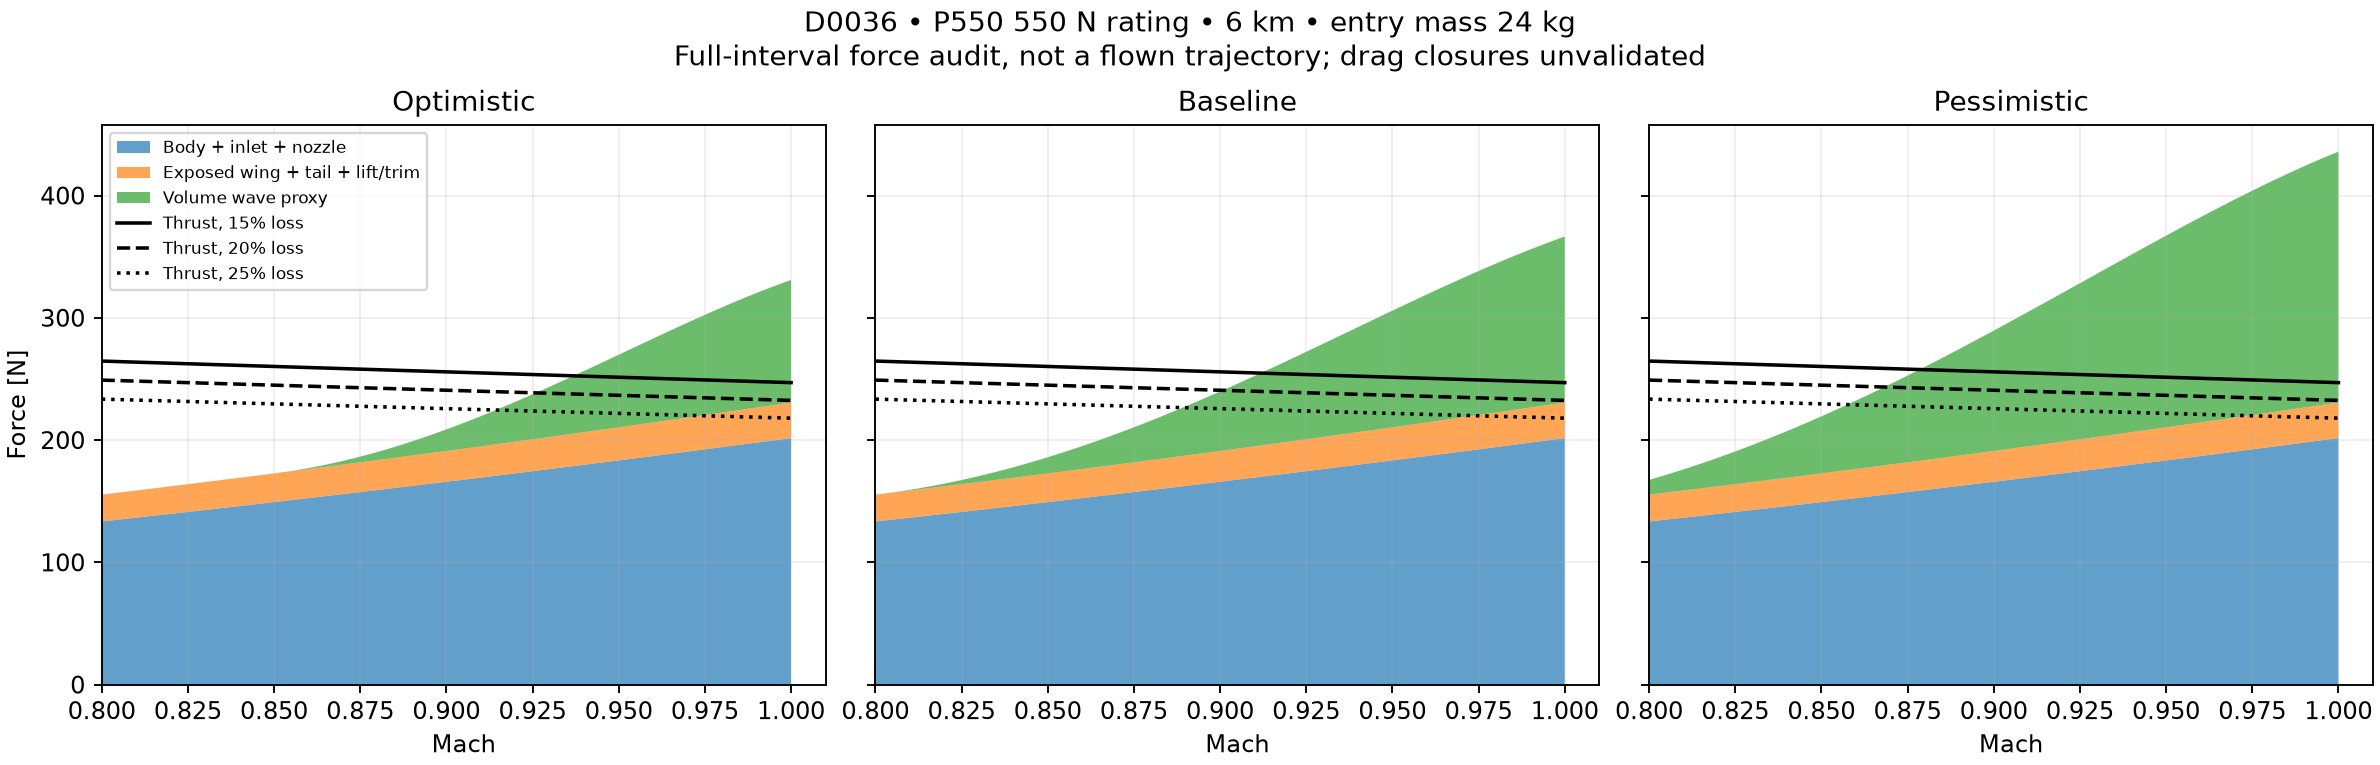

,design_id,mach1_thrust_n,mach1_body_n,mach1_wing_tail_n,mach1_baseline_wave_n,baseline_min_excess_n
0,D0027,246.99,201.65,28.00,135.73,-118.39
3,D0030,246.99,201.65,28.63,135.73,-119.03
6,D0033,246.99,201.65,28.41,135.73,-118.81
9,D0036,246.99,201.65,29.10,135.73,-119.50


In [2]:
display(Image(filename=str(out/'forces.png')))
display(force[force.installation_loss_pct == 15][['design_id','mach1_thrust_n','mach1_body_n','mach1_wing_tail_n','mach1_baseline_wave_n','baseline_min_excess_n']].round(2))

## Frozen geometry and mass assumptions

The 200 mm inlet highlight is not the maximum body diameter. The area plot accounts for the 248 mm bay envelope around the manufacturer's mounting hardware. Gross wing area remains .08 m²; only the exposed parts contribute their volume and wetted area.

The 18 kg empty budget includes the 5.4 kg engine, 10.8 kg other allocations and 1.8 kg reserve. Only the engine mass is substantiated hardware data; these remain conditional audit rows, not accepted candidates.

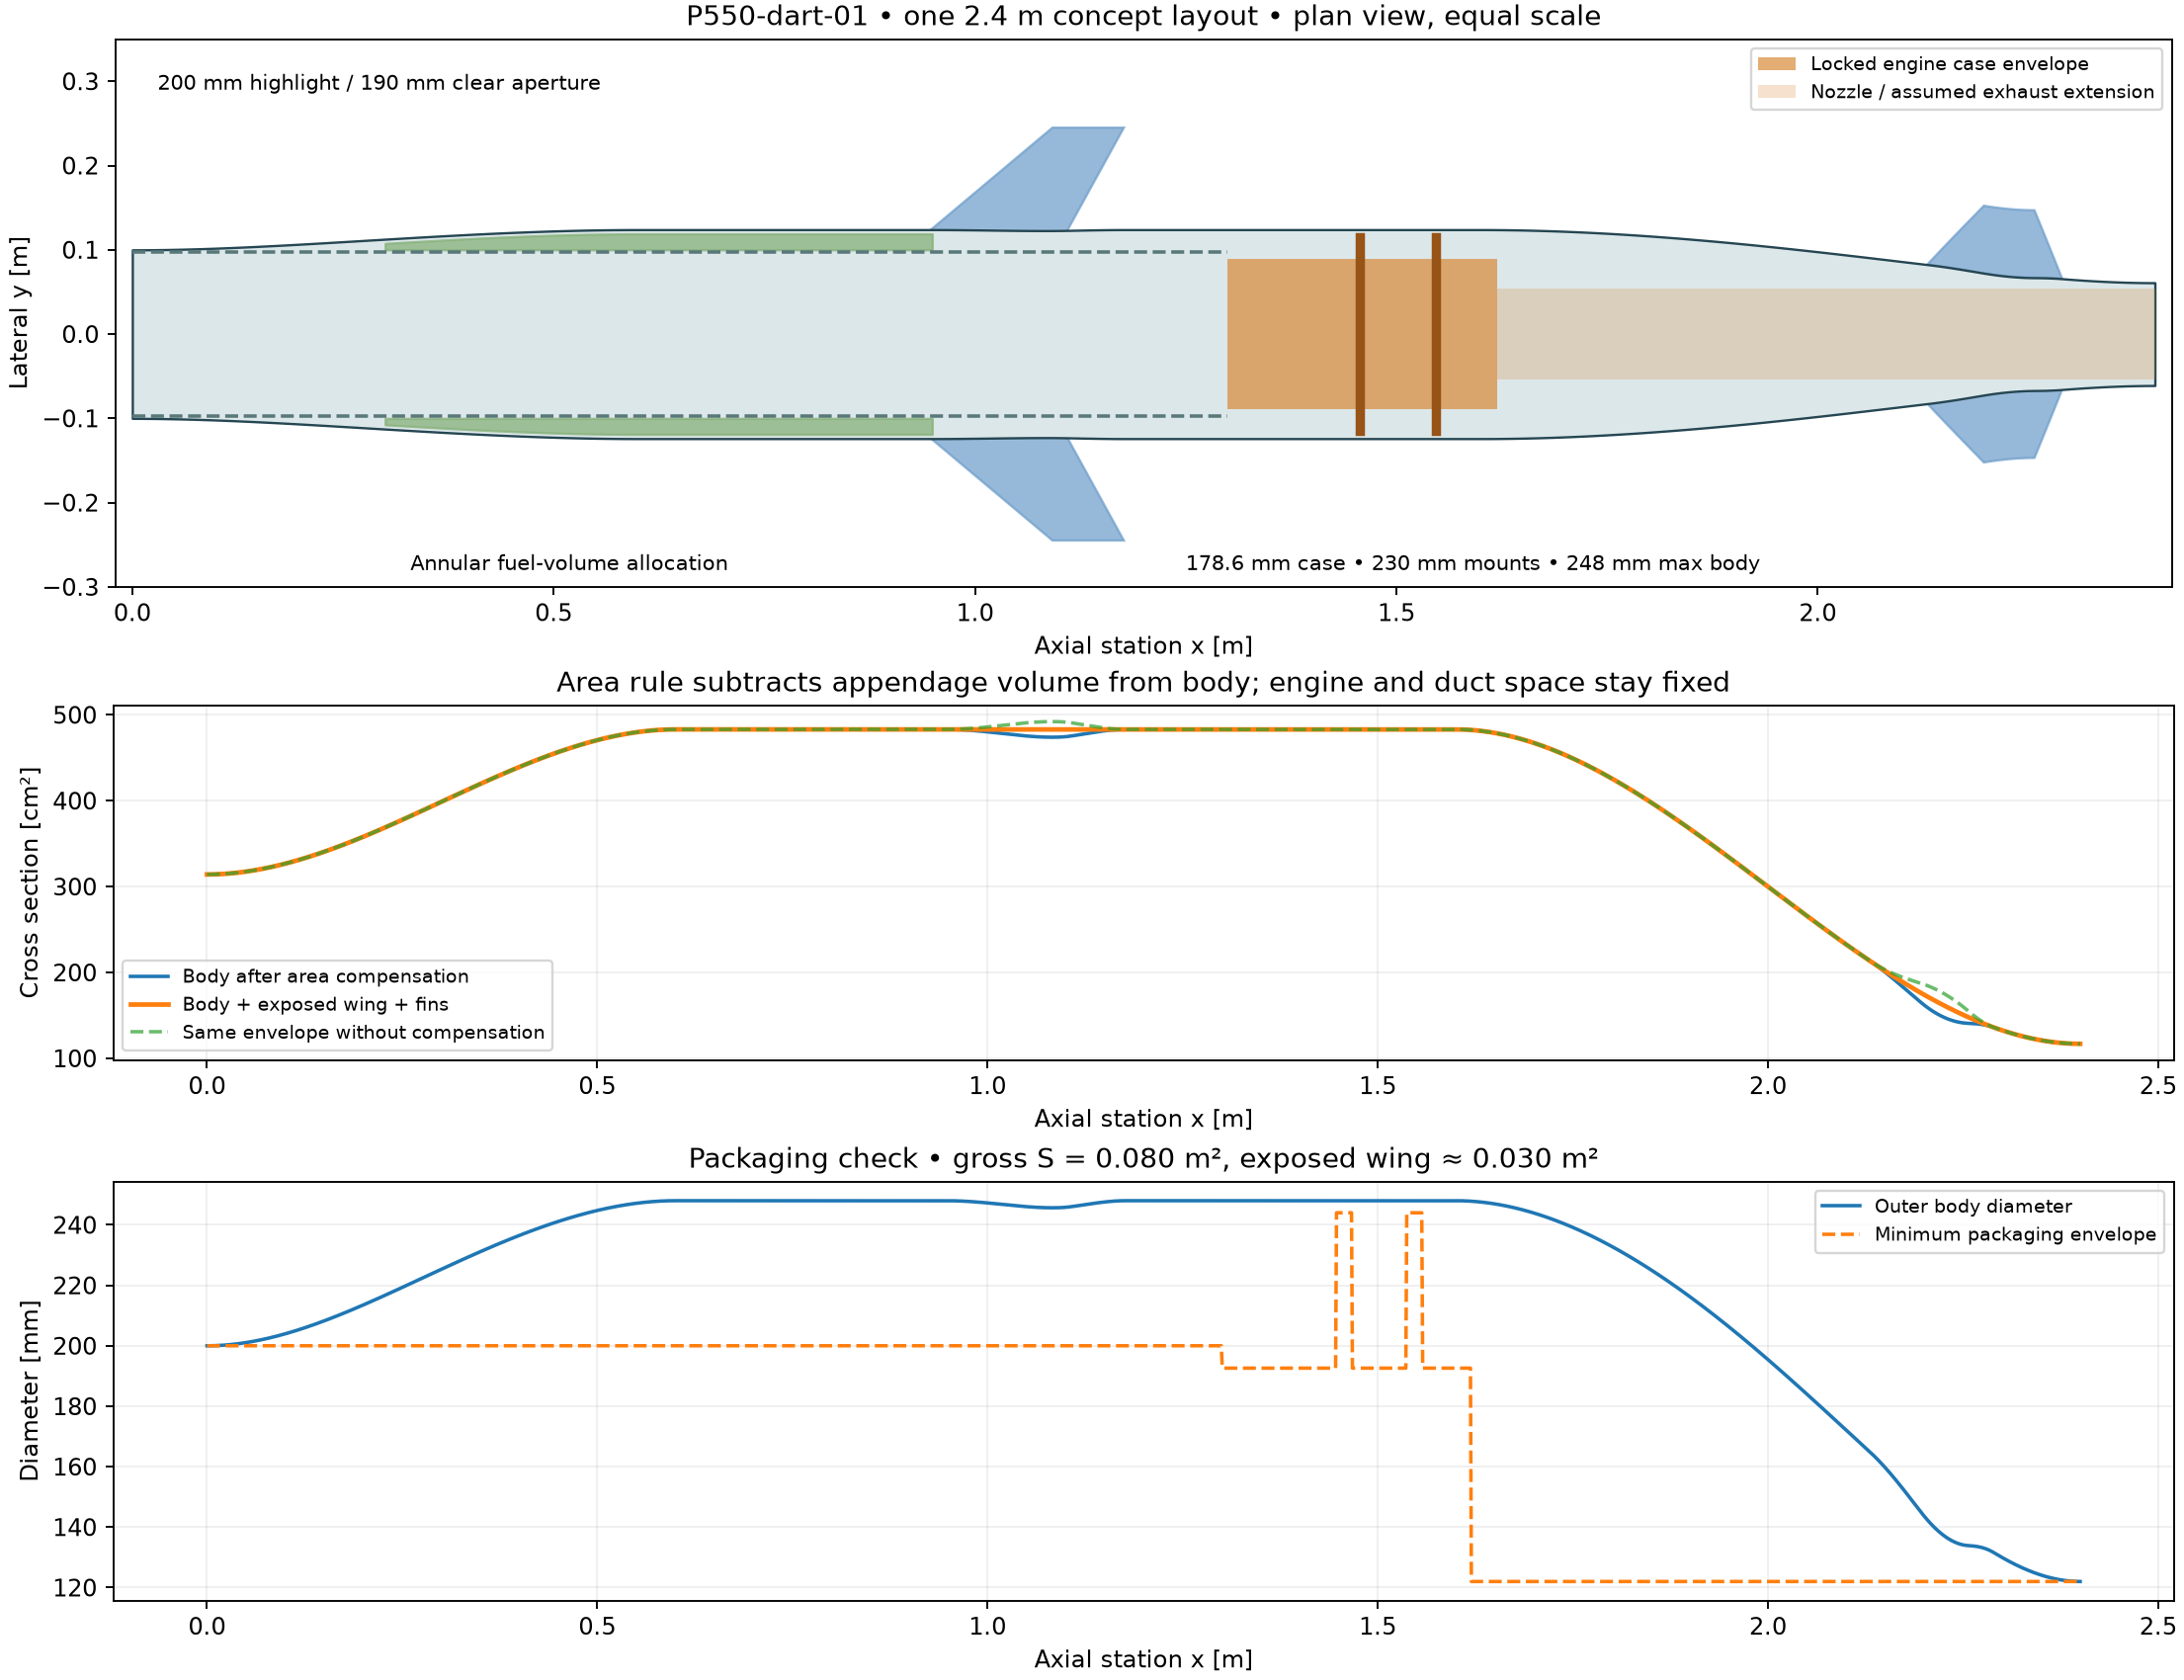

,component,kg
0,P550-PRO-S engine (manufacturer),5.4
1,body shell and frames (allocation),3.2
2,wing and fins (allocation),1.8
3,inlet and duct (allocation),1.2
4,mounts and thermal protection (allocation),1.0
5,tank and plumbing (allocation),0.8
6,avionics and actuators (allocation),0.8
7,battery and wiring (allocation),0.5
8,recovery equipment (allocation),1.0
9,fasteners and miscellaneous (allocation),0.5


In [3]:
display(Image(filename=str(out/'geometry'/'layout.png')))
display(pd.read_csv(out/'mass_budget.csv'))

In [4]:
decisions = pd.read_csv(out/'trajectory_decisions.csv')
count = int(decisions.trajectory_run.sum())
closed = bool((force[force.installation_loss_pct == 15].baseline_min_excess_n < 0).all())
print(f'Trajectories run: {count}; wave branches screened: {len(decisions)}')
print('Baseline corner CLOSED under this model.' if closed else 'Inspect surviving branches and hold results.')
display(decisions)
display(pd.read_csv(out/'numerical_convergence.csv'))
display(Markdown('No physical validation is implied by numerical convergence. Stop at this table; next work, if resumed, concerns the bay/area distribution and inlet pressure estimates.'))

Trajectories run: 0; wave branches screened: 36
Baseline corner CLOSED under this model.


,force_case_id,wave_envelope,force_pass,trajectory_run,gate_pass,endurance_pass,reason,geometry_gate_pass,empty_mass_verified
0,D0027_loss15,optimistic,False,False,NaN,NaN,negative_force_balance,False,False
1,D0027_loss15,baseline,False,False,NaN,NaN,negative_force_balance,False,False
2,D0027_loss15,pessimistic,False,False,NaN,NaN,negative_force_balance,False,False
3,D0027_loss20,optimistic,False,False,NaN,NaN,negative_force_balance,False,False
4,D0027_loss20,baseline,False,False,NaN,NaN,negative_force_balance,False,False
5,D0027_loss20,pessimistic,False,False,NaN,NaN,negative_force_balance,False,False
6,D0027_loss25,optimistic,False,False,NaN,NaN,negative_force_balance,False,False
7,D0027_loss25,baseline,False,False,NaN,NaN,negative_force_balance,False,False
8,D0027_loss25,pessimistic,False,False,NaN,NaN,negative_force_balance,False,False
9,D0030_loss15,optimistic,False,False,NaN,NaN,negative_force_balance,False,False


,check,resolution,wave_area_m2
0,Fourier modes,40,0.004196
1,Fourier modes,80,0.004205
2,Fourier modes,160,0.004207
3,Axial stations,1001,0.004205
4,Axial stations,2001,0.004205
5,Axial stations,4001,0.004205


No physical validation is implied by numerical convergence. Stop at this table; next work, if resumed, concerns the bay/area distribution and inlet pressure estimates.